<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/demos/mppi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install dynamaxsys

In [2]:
import jax.numpy as jnp
import jax
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# from aa598.hw2_helper import simulate_dynamics
import dynamaxsys
from dynamaxsys import DynamicallyExtendedSimpleCar
import equinox as eqx
from typing import Callable


In [3]:
radius = 1.0
v_max = 2.0
acceleration_max = 1.0
acceleration_min = -1.0
steering_max = 0.3
steering_min = -0.3

In [4]:
@jax.jit
def evaluate_trajectory_cost(
    robot_states,
    robot_controls,
    human_states_samples,
    coeff=[0.1, 0.3, 0.5, 0.4, 3.0, 3.0],
):
    # lower is better
    steering = robot_controls[:, 1]
    acceleration = robot_controls[:, 0]
    # steering effort
    turning_effort = (steering**2).mean()
    # acceleration effort
    acceleration_effort = (acceleration**2).mean()
    # speed limit
    speed = jax.nn.relu(robot_states[:, -1].max() - v_max) + jax.nn.relu(
        -robot_states[:, -1].min()
    )
    # progress to goal
    progress = robot_states[-1, 2] ** 2 + (robot_states[:, 1] ** 2).mean()
    # collision
    collision = jax.nn.relu(
        -(
            jnp.linalg.norm(
                (robot_states - human_states_samples)[:, :, :2], axis=-1
            ).min(-1)
            - radius
        ).mean()
    )
    # control limits
    control_limits = (
        jax.nn.relu(steering.max() - steering_max)
        + jax.nn.relu(steering_min - steering.min())
        + jax.nn.relu(acceleration.max() - acceleration_max)
        + jax.nn.relu(acceleration_min - acceleration.min())
    )

    return jnp.dot(
        jnp.array(coeff),
        jnp.array(
            [
                turning_effort,
                acceleration_effort,
                speed,
                progress,
                collision,
                control_limits,
            ]
        ),
    )


@eqx.filter_jit
def simulate_dynamics(
    dynamics: Callable[[jnp.ndarray, jnp.ndarray, float], jnp.ndarray],
    initial_state: jnp.ndarray,
    control_sequence: jnp.ndarray,
    dt: float,
) -> jnp.ndarray:
    """
    Simulate the discrete-time dynamics over a given time horizon.

    Args:
        dynamics: A callable representing the discrete-time dynamics function.
        initial_state: The initial state of the system.
        control_sequence: A sequence of control inputs for each time step.
        dt: The time step size.

    Returns:
        An array containing the state trajectory over the time horizon.
    """

    def scan_step(state, control):
        x, time = state
        x_next = dynamics(x, control, time)
        return (x_next, time + dt), x_next

    xs_ = jax.lax.scan(scan_step, (initial_state, 0), control_sequence)[1]
    xs = jnp.concatenate([initial_state[None], xs_], axis=0)
    return xs


In [5]:
planning_horizon = 25  # planning horizon to compute cost over
n_human_samples = 64  # number of human future trajectories to sample
n_robot_samples = 32  # number of robot trajectories to sample for MPPI
dt = 0.1  # timestep size
num_iterations = 20  # number of MPPI iterations
num_time_steps = 50  # number of timesteps to simulate
human_control_prediction_noise_limit = 0.25
human_control_prediction_variance = 0.25
robot_control_noise_limit = 0.25
robot_control_noise_variance = 0.25
wheelbase = 1.0

dt = 0.1
robot = dynamaxsys.get_discrete_time_dynamics(DynamicallyExtendedSimpleCar(wheelbase=wheelbase), dt)  # robot dynamics
human = dynamaxsys.get_discrete_time_dynamics(DynamicallyExtendedSimpleCar(wheelbase=wheelbase), dt)  # human dynamics

# initial states
robot_state = jnp.array([-3.0, -0.0, 0.0, 1.0])
human_state = jnp.array([-1.0, -2.0, jnp.pi / 2.0, 1.0])
# nominal controls
robot_nominal_controls = jnp.zeros([planning_horizon, robot.control_dim])
# assume human wants to follow a constant velocity mode (i.e., zero control input)
human_nominal_controls = jnp.zeros([planning_horizon, human.control_dim])

# making lists of things for plotting later
robot_trajectory = [robot_state]
human_trajectory = [human_state]
robot_controls_list = []
human_controls_list = []
human_samples = []
robot_samples = []
robot_nominal_controls_list = [robot_nominal_controls]

# turning_effort, acceleration_effort, speed, progress, collision, control_limits
coeffs = [0.1, 0.1, 5.0, 3.0, 10.0, 5.0]  # <----- try different values!

for ti in range(num_time_steps):
    # very simple human prediction model -- just gaussian noise about a constant velocity model.
    dus = jnp.clip(
        jnp.array(
            np.random.randn(n_human_samples, planning_horizon, human.control_dim)
            * human_control_prediction_variance
        ),
        -human_control_prediction_noise_limit,
        human_control_prediction_noise_limit,
    )
    human_controls_samples = jnp.clip(
        human_nominal_controls + dus,
        min=jnp.array([acceleration_min, steering_min]),
        max=jnp.array([acceleration_max, steering_max]),
    )
    human_states_samples = jax.vmap(simulate_dynamics, [None, None, 0, None])(
        human, human_state, human_controls_samples, dt
    )
    human_samples.append(human_states_samples)

    for t in range(num_iterations):
        temperature = 1 - (t / num_iterations)
        # sampling robot control trajectories
        dus = jnp.clip(
            jnp.array(
                np.random.randn(n_robot_samples, planning_horizon, robot.control_dim)
                * robot_control_noise_variance
            ),
            -robot_control_noise_limit,
            robot_control_noise_limit,
        )
        robot_controls_samples = jnp.clip(
            robot_nominal_controls + dus,
            min=jnp.array([acceleration_min, steering_min]),
            max=jnp.array([acceleration_max, steering_max]),
        )
        # simulate robot trajectory for each control trajectory sample
        robot_states_samples = jax.vmap(simulate_dynamics, [None, None, 0, None])(
            robot, robot_state, robot_controls_samples, dt
        )

        # evaluate cost of each robot trajectory sample
        trajectory_costs = jax.vmap(evaluate_trajectory_cost, [0, 0, None, None])(
            robot_states_samples, robot_controls_samples, human_states_samples, coeffs
        )
        # weight for each trajectory sample
        weights = jax.nn.softmax(-trajectory_costs / temperature).reshape([-1, 1, 1])
        # compute new nominal control using weighted sum

        robot_nominal_controls = jnp.clip(
            robot_nominal_controls + (dus * weights).sum(0),
            min=jnp.array([acceleration_min, steering_min]),
            max=jnp.array([acceleration_max, steering_max]),
        )
    robot_samples.append(robot_states_samples)
    # use final nominal control to step forward in time by one step
    robot_nominal_controls_list.append(robot_nominal_controls)
    robot_state = simulate_dynamics(robot, robot_state, robot_nominal_controls[:1], dt)[
        -1
    ]
    human_state = simulate_dynamics(
        human, human_state, human_controls_samples[0][:1], dt
    )[-1]
    # collect the new state and controls for plotting purposes
    robot_trajectory.append(robot_state)
    human_trajectory.append(human_state)
    robot_controls_list.append(robot_nominal_controls[:1])
    human_controls_list.append(human_controls_samples[0][:1])

# turn things into jnp.array
robot_trajectory = jnp.stack(robot_trajectory)
human_trajectory = jnp.stack(human_trajectory)
human_samples = jnp.stack(human_samples)
robot_samples = jnp.stack(robot_samples)
robot_controls_list = jnp.concatenate(robot_controls_list, 0)
human_controls_list = jnp.concatenate(human_controls_list, 0)


In [6]:

lower, upper = (
    jnp.stack(
        [
            robot_samples[..., :2].reshape(-1, 2).min(axis=0),
            human_samples[..., :2].reshape(-1, 2).min(axis=0),
        ]
    ).min(axis=0),
    jnp.stack(
        [
            robot_samples[..., :2].reshape(-1, 2).max(axis=0),
            human_samples[..., :2].reshape(-1, 2).max(axis=0),
        ]
    ).max(axis=0),
)
lower, upper

(Array([-3.3146405, -2.       ], dtype=float32),
 Array([6.6360946, 6.842319 ], dtype=float32))

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


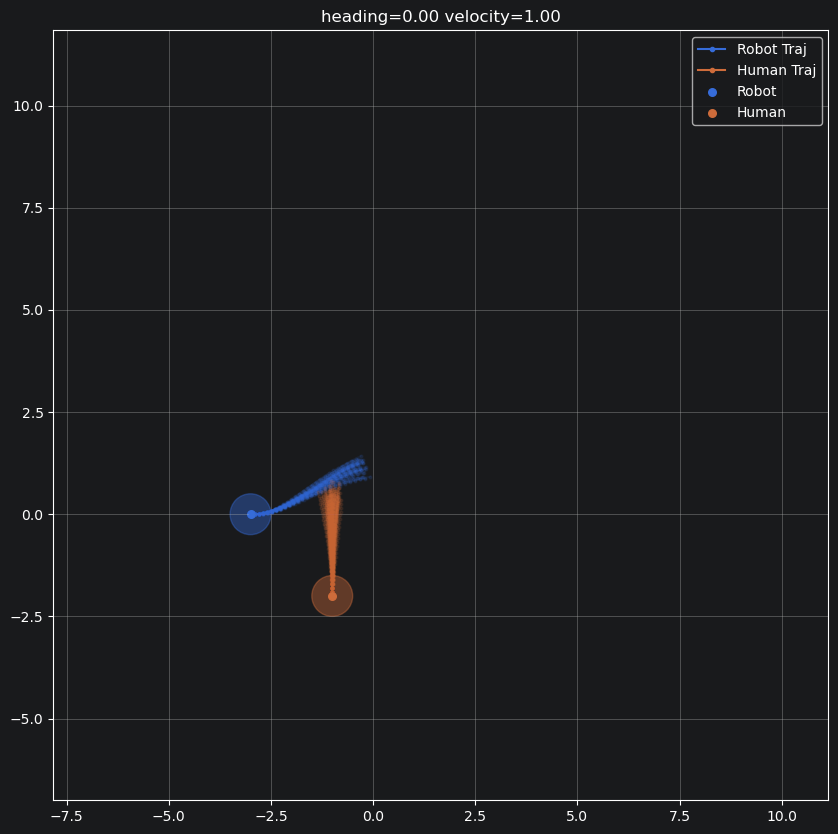

In [7]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10, 10))


def init():
    ax.clear()
    ax.set_xlim([-4, 4])
    ax.set_ylim([-3, 6])
    ax.grid()
    ax.legend()
    return []

# Animation for MPPI (no planned trajectory, no sqp_iteration_list, no robot_trajectory_list)
(robot_traj,) = ax.plot([], [], "o-", markersize=3, color="C0", label="Robot Traj")
(human_traj,) = ax.plot([], [], "o-", markersize=3, color="C1", label="Human Traj")
robot_point = ax.scatter([], [], s=30, color="C0", label="Robot")
human_point = ax.scatter([], [], s=30, color="C1", label="Human")
circle1 = plt.Circle((0, 0), radius / 2, color="C0", alpha=0.4)
circle2 = plt.Circle((0, 0), radius / 2, color="C1", alpha=0.4)
ax.add_patch(circle1)
ax.add_patch(circle2)

def animate(i):
    ax.clear()
    # Set up limits and grids
    ax.set_xlim([-4, 4])
    ax.set_ylim([-3, 6])
    ax.grid()
    # Plot robot and human positions as circles
    robot_position = robot_trajectory[i, :2]
    human_position = human_trajectory[i, :2]
    circle1 = plt.Circle(robot_position, radius / 2, color="C0", alpha=0.4)
    circle2 = plt.Circle(human_position, radius / 2, color="C1", alpha=0.4)
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    # Plot all trajectories up to step i
    ax.plot(
        robot_trajectory[: i + 1, 0],
        robot_trajectory[: i + 1, 1],
        "o-",
        markersize=3,
        color="C0",
        label="Robot Traj",
    )
    ax.plot(
        human_trajectory[: i + 1, 0],
        human_trajectory[: i + 1, 1],
        "o-",
        markersize=3,
        color="C1",
        label="Human Traj",
    )
    # Current robot and human point
    ax.scatter(
        robot_trajectory[i : i + 1, 0],
        robot_trajectory[i : i + 1, 1],
        s=30,
        color="C0",
        label="Robot",
    )
    ax.scatter(
        human_trajectory[i : i + 1, 0],
        human_trajectory[i : i + 1, 1],
        s=30,
        color="C1",
        label="Human",
    )

    ax.plot(
        robot_samples[i, :, :, 0].T,
        robot_samples[i, :, :, 1].T,
        "o-",
        alpha=0.1,
        markersize=2,
        color="C0",
    )

    ax.plot(
        human_samples[i, :, :, 0].T,
        human_samples[i, :, :, 1].T,
        "o-",
        alpha=0.1,
        markersize=2,
        color="C1",
    )

    ax.set_title(
        "heading=%.2f velocity=%.2f" % (robot_trajectory[i, 2], robot_trajectory[i, 3])
    )
    ax.legend()
    ax.axis("equal")
    eps = 5
    ax.set_xlim([lower[0] - eps, upper[0] + eps])
    ax.set_ylim([lower[1] - eps, upper[1] + eps])

ani = animation.FuncAnimation(
    fig, animate, frames=num_time_steps, interval=150, blit=False, repeat=True
)

HTML(ani.to_jshtml())

In [8]:
@interact(i=(0, num_time_steps - 1))
def plot(i):
    fig, axs = plt.subplots(1, 2, figsize=(18, 8))
    ax = axs[0]
    robot_position = robot_trajectory[i, :2]
    human_position = human_trajectory[i, :2]
    circle1 = plt.Circle(robot_position, radius / 2, color="C0", alpha=0.4)
    circle2 = plt.Circle(human_position, radius / 2, color="C1", alpha=0.4)
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    ax.plot(
        human_samples[i, :, :, 0].T,
        human_samples[i, :, :, 1].T,
        "o-",
        alpha=0.1,
        markersize=2,
        color="C1",
    )
    ax.plot(
        robot_trajectory[:, 0], robot_trajectory[:, 1], "o-", markersize=3, color="C0"
    )
    ax.plot(
        human_trajectory[:, 0], human_trajectory[:, 1], "o-", markersize=3, color="C1"
    )
    ax.scatter(
        robot_trajectory[i : i + 1, 0],
        robot_trajectory[i : i + 1, 1],
        s=30,
        color="C0",
        label="Robot",
    )
    ax.scatter(
        human_trajectory[i : i + 1, 0],
        human_trajectory[i : i + 1, 1],
        s=30,
        color="C1",
        label="Human",
    )
    ax.grid()
    ax.legend()
    ax.axis("equal")
    ax.set_xlim([-4, 4])
    ax.set_ylim([-3, 6])

    ax.set_title(
        "heading=%.2f velocity=%.2f" % (robot_trajectory[i, 2], robot_trajectory[i, 3])
    )

    ax = axs[1]
    plt.plot(robot_controls_list)
    plt.scatter([i], robot_controls_list[i : i + 1, 0], label="Acceleration")
    plt.scatter([i], robot_controls_list[i : i + 1, 1], label="Steering")
    ax.plot(robot_trajectory[:, -1], "o-", markersize=3, color="C0", label="Velocity")

    ax.legend()
    ax.grid()

interactive(children=(IntSlider(value=24, description='i', max=49), Output()), _dom_classes=('widget-interact'…